In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("../data/telecom_churn.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
state_enc = LabelEncoder()
df["State"] = state_enc.fit_transform(df["State"])
df["International plan"] = (df["International plan"] == "Yes").astype("int")
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype("int")
df["Churn"] = (df["Churn"]).astype("int")

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Churn", axis=1),
    df["Churn"],
    test_size=0.3,
    stratify=df["Churn"],
    random_state=17,
)
dtrain = xgb.DMatrix(X_train, y_train)
dtest = xgb.DMatrix(X_test, y_test)

In [5]:
print("Train dataset contains {0} rows and {1} columns".format(dtrain.num_row(), dtrain.num_col()))
print("Test dataset contains {0} rows and {1} columns".format(dtest.num_row(), dtest.num_col()))

Train dataset contains 2333 rows and 19 columns
Test dataset contains 1000 rows and 19 columns


In [6]:
print("Train mean target: ")
print(np.mean(dtrain.get_label()))

print("\nTest mean target: ")
print(np.mean(dtest.get_label()))

Train mean target: 
0.14487784

Test mean target: 
0.145


In [7]:
params = {"objective": "binary:logistic", "max_depth": 3, "eta": 1}
num_rounds = 50

In [8]:
xgb_model = xgb.train(params, dtrain, num_rounds)

In [9]:
watchlist = [(dtest, "test"), (dtrain, "train")]
xgb_model = xgb.train(params, dtrain, num_rounds, watchlist)

[0]	test-logloss:0.33273	train-logloss:0.27445
[1]	test-logloss:0.32641	train-logloss:0.21555
[2]	test-logloss:0.29546	train-logloss:0.18468
[3]	test-logloss:0.30183	train-logloss:0.17380
[4]	test-logloss:0.29615	train-logloss:0.15904
[5]	test-logloss:0.30501	train-logloss:0.15088
[6]	test-logloss:0.28436	train-logloss:0.14083
[7]	test-logloss:0.27038	train-logloss:0.12572
[8]	test-logloss:0.26869	train-logloss:0.12037
[9]	test-logloss:0.27546	train-logloss:0.11524
[10]	test-logloss:0.27826	train-logloss:0.11139
[11]	test-logloss:0.27416	train-logloss:0.10676
[12]	test-logloss:0.27109	train-logloss:0.10407
[13]	test-logloss:0.26927	train-logloss:0.10014
[14]	test-logloss:0.26728	train-logloss:0.09745
[15]	test-logloss:0.27184	train-logloss:0.09257
[16]	test-logloss:0.27047	train-logloss:0.08798
[17]	test-logloss:0.26623	train-logloss:0.08149
[18]	test-logloss:0.26103	train-logloss:0.07808
[19]	test-logloss:0.26156	train-logloss:0.07594
[20]	test-logloss:0.26557	train-logloss:0.07275
[2

/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/xgboost/core.py:550: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


In [10]:
preds_prob = xgb_model.predict(dtest)

predicted_labels = preds_prob > 0.5
print(
    "Accuracy and F1 on the test set are: {} and {}".format(
    round(accuracy_score(y_test, predicted_labels), 3),
    round(f1_score(y_test, predicted_labels), 3),
    )
)

Accuracy and F1 on the test set are: 0.929 and 0.719


# Важность признаков

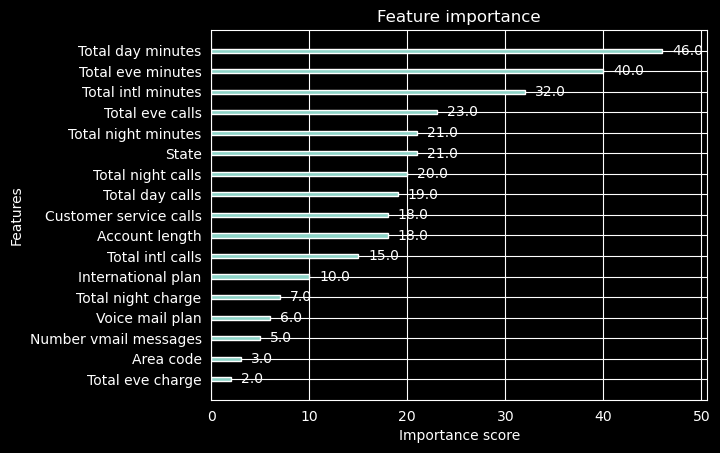

In [11]:
xgb.plot_importance(xgb_model);

In [12]:
importances = xgb_model.get_fscore()
importances

{'State': 21.0,
 'Account length': 18.0,
 'Area code': 3.0,
 'International plan': 10.0,
 'Voice mail plan': 6.0,
 'Number vmail messages': 5.0,
 'Total day minutes': 46.0,
 'Total day calls': 19.0,
 'Total eve minutes': 40.0,
 'Total eve calls': 23.0,
 'Total eve charge': 2.0,
 'Total night minutes': 21.0,
 'Total night calls': 20.0,
 'Total night charge': 7.0,
 'Total intl minutes': 32.0,
 'Total intl calls': 15.0,
 'Customer service calls': 18.0}

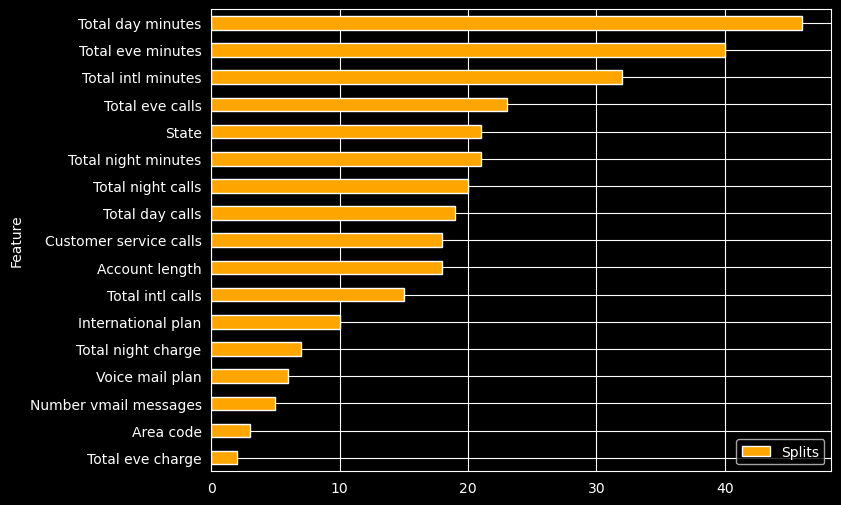

In [13]:
importance_df = pd.DataFrame(
    {"Splits": list(importances.values()), "Feature": list(importances.keys())}
)
importance_df.sort_values(by="Splits", inplace=True)
importance_df.plot(kind="barh", x="Feature", figsize=(8, 6), color="orange");